# Handwritten Text Recognition from Document Images

## Objective
This notebook builds and evaluates a deep learning pipeline for handwritten text recognition from document images.

The goal is to convert handwritten content into machine-readable text while handling different handwriting styles, noise, and image quality.

## Notebook Organization
1. Data preparation
2. Data splitting
3. Model definition
4. Model training
5. Testing
6. Evaluation
7. Model comparison
8. Explainability (XAI)

## Models Compared
- CRNN with LSTM
- CRNN with GRU
- Deep CRNN
- TrOCR pretrained transformer model


# 1. Environment Setup

This section installs required packages, imports libraries, and defines global configuration values such as image size, batch size, learning rate, and dataset paths.


In [4]:
!pip install editdistance -q

import os
import re
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import torchvision.transforms as T
from PIL import Image
import editdistance
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
IAM_ROOT   = "/kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words"
WORDS_TXT  = "/kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words/words.txt"
WORDS_DIR  = "/kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words/words"

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 3e-4
IMG_H      = 32
IMG_W      = 128

print(f"Device      : {DEVICE}")
print(f"IAM root    : {os.listdir(IAM_ROOT)}")
print(f"Words dir   : {os.listdir(WORDS_DIR)[:5]}  ...")  # show first 5 subfolders


Device      : cuda
IAM root    : ['words.txt', 'words']
Words dir   : ['g05', 'm03', 'd06', 'a04', 'b05']  ...


# 2. Data Preparation

This stage prepares both the image data and the text labels before training.

It includes label encoding, image preprocessing, document cleaning, and segmentation utilities used later for full-document OCR.


## 2.1 Dataset Description

We use the IAM handwritten word dataset, which contains word images and their corresponding text transcriptions.

The OCR task is to learn a mapping from an image of handwritten text to its correct text sequence.


## 2.2 Label Preprocessing

Text labels are converted into numerical sequences using a fixed character vocabulary.

The index `0` is reserved for the CTC blank token, while all other characters are mapped to integer IDs.


In [5]:
# ── Character vocabulary ──────────────────────────────────────────────────────
CHARSET = (
    " !\"#&'()*+,-./0123456789:;?"
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "abcdefghijklmnopqrstuvwxyz"
)
char2idx = {c: i + 1 for i, c in enumerate(CHARSET)}  # 0 reserved for CTC blank
idx2char = {i: c for c, i in char2idx.items()}
VOCAB_SIZE = len(char2idx) + 1   # +1 for blank

def encode(text: str) -> list:
    return [char2idx[c] for c in text if c in char2idx]

def decode(indices: list) -> str:
    return "".join(idx2char.get(i, "") for i in indices)

# ── Parse IAM ground-truth label file ────────────────────────────────────────
def parse_words_txt(words_txt_path) -> dict:
    """
    Returns {word_id: transcription} from ascii/words_new.txt
    Skips lines marked as 'err' (bad segmentation in the original dataset).
    """
    labels = {}
    with open(words_txt_path, "r") as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split(" ")
            if len(parts) < 9 or parts[1] == "err":
                continue
            word_id      = parts[0]    # e.g. a01-000u-00-00
            transcription = parts[-1]  # last token is the word
            labels[word_id] = transcription
    return labels

# Quick sanity check
# Quick sanity check — now pointing to the correct path
labels = parse_words_txt(WORDS_TXT)
print(f"Total labeled words: {len(labels)}")
print("Sample:", list(labels.items())[:5])


Total labeled words: 38305
Sample: [('a01-000u-00-00', 'A'), ('a01-000u-00-01', 'MOVE'), ('a01-000u-00-02', 'to'), ('a01-000u-00-03', 'stop'), ('a01-000u-00-04', 'Mr.')]


## 2.3 Image Preprocessing for Word Crops

Word images are resized while preserving aspect ratio, padded to a fixed size, converted to grayscale, and normalized.

During training, small augmentations are applied to improve robustness to handwriting variation.


In [6]:
# ---------- 1) SAME PREPROCESS FOR TRAINING AND INFERENCE ----------
class ResizePadNormalize:
    """
    Keep aspect ratio, resize to fit inside (IMG_H, IMG_W),
    pad with white background, then normalize to [-1, 1].
    """
    def __init__(self, target_h=32, target_w=128):
        self.target_h = target_h
        self.target_w = target_w

    def __call__(self, img):
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        img = img.convert('L')
        arr = np.array(img)

        # Ensure white background + dark text
        if arr.mean() < 127:
            arr = 255 - arr
        img = Image.fromarray(arr)

        w, h = img.size
        if w == 0 or h == 0:
            canvas = Image.new('L', (self.target_w, self.target_h), color=255)
        else:
            scale = min(self.target_w / w, self.target_h / h)
            new_w = max(1, int(round(w * scale)))
            new_h = max(1, int(round(h * scale)))

            img = img.resize((new_w, new_h), Image.BICUBIC)

            canvas = Image.new('L', (self.target_w, self.target_h), color=255)
            x = (self.target_w - new_w) // 2
            y = (self.target_h - new_h) // 2
            canvas.paste(img, (x, y))

        tensor = T.ToTensor()(canvas)
        tensor = T.Normalize(mean=[0.5], std=[0.5])(tensor)
        return tensor


def build_word_transform(augment=False):
    if augment:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            T.RandomRotation(degrees=2, fill=255),
            T.RandomAffine(degrees=0, translate=(0.02, 0.02), shear=3, fill=255),
            ResizePadNormalize(IMG_H, IMG_W),
        ])
    else:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            ResizePadNormalize(IMG_H, IMG_W),
        ])


## 2.4 Document Preprocessing for Real Images

For full document images, stronger preprocessing is required before OCR.

This includes deskewing, denoising, contrast enhancement, binarization, removing small artifacts, and keeping the main text block.


In [7]:
# ---------- 2) DESKEW + BETTER BINARIZATION ----------
def deskew_image(gray: np.ndarray) -> np.ndarray:
    tmp = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(tmp > 0))
    if len(coords) < 50:
        return gray

    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    angle = -angle

    if abs(angle) < 0.3:
        return gray

    h, w = gray.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# ============================================================
# KEEP ONLY MAIN TEXT BLOCK
# ============================================================

def keep_main_text_block(binary: np.ndarray, pad: int = 12):
    """
    binary: 255=text, 0=background
    keep only the main connected text zone to remove border noise / extra artifacts
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    H, W = binary.shape
    candidates = []

    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # ignore very tiny blobs
        if area < 20:
            continue

        # ignore components touching borders too much
        touches_border = (x <= 1 or y <= 1 or (x + w) >= W - 1 or (y + h) >= H - 1)
        border_penalty = 0.6 if touches_border else 1.0

        # prefer large central components
        cx = x + w / 2
        cy = y + h / 2
        dist_to_center = ((cx - W/2) ** 2 + (cy - H/2) ** 2) ** 0.5
        center_score = 1.0 / (1.0 + dist_to_center / max(W, H))

        score = area * center_score * border_penalty
        candidates.append((i, score, x, y, w, h, area))

    if not candidates:
        return binary

    # sort by score descending
    candidates.sort(key=lambda t: t[1], reverse=True)

    # take the best component, then merge close neighbors
    best = candidates[0]
    _, _, bx, by, bw, bh, _ = best

    x0 = bx
    y0 = by
    x1 = bx + bw
    y1 = by + bh

    # merge nearby components
    for comp in candidates[1:]:
        _, _, x, y, w, h, area = comp

        cx = x + w / 2
        cy = y + h / 2
        main_cx = (x0 + x1) / 2
        main_cy = (y0 + y1) / 2

        close_horiz = abs(cx - main_cx) < W * 0.35
        close_vert  = abs(cy - main_cy) < H * 0.25

        if close_horiz and close_vert:
            x0 = min(x0, x)
            y0 = min(y0, y)
            x1 = max(x1, x + w)
            y1 = max(y1, y + h)

    x0 = max(0, x0 - pad)
    y0 = max(0, y0 - pad)
    x1 = min(W, x1 + pad)
    y1 = min(H, y1 + pad)

    cleaned = np.zeros_like(binary)
    cleaned[y0:y1, x0:x1] = binary[y0:y1, x0:x1]

    return cleaned

# ============================================================
# LOAD + BINARIZE + KEEP MAIN TEXT BLOCK
# ============================================================

def load_and_binarize_clean(img_path: str, show: bool = False):
    """
    Returns (img_bgr, gray_deskewed, binary)
    binary = 255 for text / 0 for background
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f'Cannot read image: {img_path}')

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = deskew_image(gray)

    gray = cv2.fastNlMeansDenoising(gray, None, 12, 7, 21)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    binary = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 12
    )

    # remove tiny noise
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    cleaned = np.zeros_like(binary)
    H, W = binary.shape
    max_blob = 0.08 * H * W

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if 4 <= area <= max_blob:
            cleaned[labels == i] = 255

    # morphology
    k1 = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    k2 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 1))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, k1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, k2)

    # keep only the main text zone
    cleaned = keep_main_text_block(cleaned)

    if show:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
        axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Deskewed gray'); axes[1].axis('off')
        axes[2].imshow(binary, cmap='gray'); axes[2].set_title('Adaptive binary'); axes[2].axis('off')
        axes[3].imshow(cleaned, cmap='gray'); axes[3].set_title('Main text block only'); axes[3].axis('off')
        plt.tight_layout(); plt.show()

    return img, gray, cleaned


## 2.5 Segmentation Utilities

These helper functions crop text regions, detect text lines, segment words, and convert word images into tensors.

They are mainly used when testing the OCR pipeline on full document images.


In [8]:
# ---------- 3) TIGHT CROP ----------
def tight_crop(mask: np.ndarray, pad: int = 2):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    y0 = max(0, ys.min() - pad)
    y1 = min(mask.shape[0], ys.max() + 1 + pad)
    x0 = max(0, xs.min() - pad)
    x1 = min(mask.shape[1], xs.max() + 1 + pad)
    return mask[y0:y1, x0:x1], (x0, y0, x1, y1)

# ============================================================
# STRONGER LINE SEGMENTATION
# ============================================================
def segment_lines_robust(binary: np.ndarray,
                         min_line_height: int = 14,
                         padding: int = 4,
                         row_ratio_thresh: float = 0.015) -> list:
    fg = (binary > 0).astype(np.uint8)
    h_proj = fg.sum(axis=1).astype(np.float32)
    h_proj = np.convolve(h_proj, np.ones(7) / 7, mode='same')

    thresh = max(3, int(binary.shape[1] * row_ratio_thresh))

    lines = []
    in_line = False
    y_start = 0

    for y, val in enumerate(h_proj):
        if val >= thresh and not in_line:
            in_line = True
            y_start = y
        elif val < thresh and in_line:
            in_line = False
            if (y - y_start) >= min_line_height:
                y0 = max(0, y_start - padding)
                y1 = min(binary.shape[0], y + padding)

                strip = binary[y0:y1, :]
                col_sums = (strip > 0).sum(axis=0)
                nz = np.where(col_sums > 0)[0]
                if len(nz) == 0:
                    continue

                x0 = max(0, int(nz[0]) - padding)
                x1 = min(binary.shape[1], int(nz[-1]) + 1 + padding)

                candidate = strip[:, x0:x1]
                ink = int((candidate > 0).sum())
                area = candidate.shape[0] * candidate.shape[1]
                ink_ratio = ink / float(area + 1e-6)

                if ink >= 60 and ink_ratio >= 0.01:
                    lines.append({
                        'img': candidate,
                        'y_start': y0, 'y_end': y1,
                        'x_start': x0, 'x_end': x1
                    })

    if in_line and (binary.shape[0] - y_start) >= min_line_height:
        y0 = max(0, y_start - padding)
        y1 = binary.shape[0]

        strip = binary[y0:y1, :]
        col_sums = (strip > 0).sum(axis=0)
        nz = np.where(col_sums > 0)[0]
        if len(nz) > 0:
            x0 = max(0, int(nz[0]) - padding)
            x1 = min(binary.shape[1], int(nz[-1]) + 1 + padding)

            candidate = strip[:, x0:x1]
            ink = int((candidate > 0).sum())
            area = candidate.shape[0] * candidate.shape[1]
            ink_ratio = ink / float(area + 1e-6)

            if ink >= 60 and ink_ratio >= 0.01:
                lines.append({
                    'img': candidate,
                    'y_start': y0, 'y_end': y1,
                    'x_start': x0, 'x_end': x1
                })

    return lines

# ---------- 5) BETTER WORD SEGMENTATION ----------
def segment_words_robust(line_img: np.ndarray,
                         min_word_width: int = 8,
                         min_gap: int = 12,
                         min_ink_pixels: int = 20,
                         padding: int = 2) -> list:
    fg = (line_img > 0).astype(np.uint8)
    v_proj = fg.sum(axis=0).astype(np.float32)
    if v_proj.max() == 0:
        return []

    v_proj = np.convolve(v_proj, np.ones(5) / 5, mode='same')
    threshold = max(1, int(0.12 * v_proj.max()))

    words = []
    in_word = False
    start = 0
    gap_count = 0

    for x, val in enumerate(v_proj):
        if val >= threshold:
            if not in_word:
                in_word = True
                start = x
            gap_count = 0
        elif in_word:
            gap_count += 1
            if gap_count >= min_gap:
                end = x - gap_count + 1
                in_word = False
                if (end - start) >= min_word_width:
                    x0 = max(0, start - padding)
                    x1 = min(line_img.shape[1], end + padding)
                    word = line_img[:, x0:x1]
                    result = tight_crop(word, pad=2)
                    if result is None:
                        gap_count = 0
                        continue
                    word_crop, (cx0, cy0, cx1, cy1) = result
                    if (word_crop > 0).sum() >= min_ink_pixels and word_crop.shape[0] >= 8 and word_crop.shape[1] >= 8:
                        words.append({
                            'img': word_crop,
                            'x_start': x0 + cx0, 'x_end': x0 + cx1,
                            'y_start': cy0, 'y_end': cy1
                        })
                gap_count = 0

    if in_word:
        x0 = max(0, start - padding)
        x1 = line_img.shape[1]
        word = line_img[:, x0:x1]
        result = tight_crop(word, pad=2)
        if result is not None:
            word_crop, (cx0, cy0, cx1, cy1) = result
            if (word_crop > 0).sum() >= min_ink_pixels and word_crop.shape[0] >= 8 and word_crop.shape[1] >= 8:
                words.append({
                    'img': word_crop,
                    'x_start': x0 + cx0, 'x_end': x0 + cx1,
                    'y_start': cy0, 'y_end': cy1
                })

    return words


# ---------- 6) WORD IMAGE TO TENSOR ----------
def resize_and_pad_word(word_img: np.ndarray, target_h: int = 32, target_w: int = 128) -> np.ndarray:
    if len(word_img.shape) == 3:
        word_img = cv2.cvtColor(word_img, cv2.COLOR_BGR2GRAY)

    if word_img.mean() < 127:
        word_img = 255 - word_img

    h, w = word_img.shape[:2]
    if h == 0 or w == 0:
        return np.ones((target_h, target_w), dtype=np.uint8) * 255

    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(word_img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

    canvas = np.ones((target_h, target_w), dtype=np.uint8) * 255
    y = (target_h - new_h) // 2
    x = (target_w - new_w) // 2
    canvas[y:y+new_h, x:x+new_w] = resized
    return canvas


def word_to_tensor(word_gray: np.ndarray) -> torch.Tensor:
    padded = resize_and_pad_word(word_gray, IMG_H, IMG_W)
    arr = padded.astype(np.float32) / 255.0
    arr = (arr - 0.5) / 0.5
    return torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)


# 3. Data Splitting

The dataset is split into training, validation, and test sets using an 80/10/10 ratio.

The training set is used to learn model parameters, the validation set is used during training, and the test set is used for final evaluation.


In [9]:
class IAMWordsDataset(Dataset):
    MIN_W = 16   # skip images narrower than this (avoids blur crash)
    MIN_H = 8    # skip images shorter than this

    def __init__(self, root: str, words_txt: str, words_dir: str,
                 split: str = "train", augment: bool = False):
        assert split in ("train", "val", "test")
        self.words_dir = Path(words_dir)
        self.augment   = augment

        all_labels = parse_words_txt(words_txt)

        # Build list of valid samples — image must exist AND be large enough
        all_samples = []
        skipped = 0
        for word_id, text in all_labels.items():
            parts    = word_id.split("-")
            folder1  = parts[0]
            folder2  = f"{parts[0]}-{parts[1]}"
            img_path = self.words_dir / folder1 / folder2 / f"{word_id}.png"

            if not img_path.exists() or len(text) == 0:
                continue

            # Check image dimensions before adding
            try:
                with Image.open(img_path) as im:
                    w, h = im.size
                    if w < self.MIN_W or h < self.MIN_H:
                        skipped += 1
                        continue
            except Exception:
                skipped += 1
                continue

            all_samples.append((img_path, text))

        print(f"Valid samples: {len(all_samples)}  |  Skipped (too small/corrupt): {skipped}")

        # Deterministic 80 / 10 / 10 split
        total   = len(all_samples)
        n_train = int(total * 0.80)
        n_val   = int(total * 0.10)

        if split == "train":
            self.samples = all_samples[:n_train]
        elif split == "val":
            self.samples = all_samples[n_train : n_train + n_val]
        else:
            self.samples = all_samples[n_train + n_val:]

        self.transform = self._build_transform(augment)
        print(f"[{split}] {len(self.samples)} samples ready")

    def _build_transform(self, augment: bool):
        ops = [T.Grayscale(num_output_channels=1)]
        if augment:
            ops += [
                T.RandomRotation(degrees=3),
                T.RandomAffine(degrees=0, shear=5),
                T.ColorJitter(brightness=0.3, contrast=0.3),
                # Resize BEFORE GaussianBlur so the image is always large enough
                T.Resize((IMG_H, IMG_W)),
                T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            ]
        else:
            ops += [T.Resize((IMG_H, IMG_W))]

        ops += [
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5]),
        ]
        return T.Compose(ops)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, text = self.samples[idx]
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            # Fallback: return a blank image if file is corrupt
            img = Image.new("RGB", (IMG_W, IMG_H), color=255)
        img   = self.transform(img)
        label = torch.tensor(encode(text), dtype=torch.long)
        return img, label, text


def collate_fn(batch):
    imgs, labels, texts = zip(*batch)
    imgs          = torch.stack(imgs)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_padded = torch.zeros(len(labels), max(label_lengths), dtype=torch.long)
    for i, l in enumerate(labels):
        labels_padded[i, :len(l)] = l
    return imgs, labels_padded, label_lengths, list(texts)


def get_dataloaders():
    train_ds = IAMWordsDataset(IAM_ROOT, WORDS_TXT, WORDS_DIR, split="train", augment=True)
    val_ds   = IAMWordsDataset(IAM_ROOT, WORDS_TXT, WORDS_DIR, split="val",   augment=False)
    test_ds  = IAMWordsDataset(IAM_ROOT, WORDS_TXT, WORDS_DIR, split="test",  augment=False)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
    return train_dl, val_dl, test_dl

# Use the improved aspect-ratio preserving preprocessing defined above
IAMWordsDataset._build_transform = lambda self, augment: build_word_transform(augment)
print('✅ Dataset transform patched: aspect-ratio resize + padding is used.')

# Rebuild dataloaders with the fix
train_dl, val_dl, test_dl = get_dataloaders()


✅ Dataset transform patched: aspect-ratio resize + padding is used.
Valid samples: 35664  |  Skipped (too small/corrupt): 2641
[train] 28531 samples ready
Valid samples: 35664  |  Skipped (too small/corrupt): 2641
[val] 3566 samples ready
Valid samples: 35664  |  Skipped (too small/corrupt): 2641
[test] 3567 samples ready


# 4. Model Definition

This section defines all OCR models used in the notebook.

We first define custom CRNN architectures trained from scratch, then add TrOCR as a pretrained transformer-based OCR model for comparison.


## 4.1 CRNN Models (LSTM / GRU / Deep CRNN)

In this part, we experiment with Convolutional Recurrent Neural Networks for handwritten text recognition.

The input images are processed by convolutional layers to extract visual features. These features are then converted into sequences and passed through recurrent layers to model text order.

We test three architectures:
- **CRNN (LSTM)**: captures long-term dependencies
- **CRNN (GRU)**: faster and uses fewer parameters
- **Deep CRNN**: deeper CNN for stronger feature extraction

The models are trained using CTC Loss and evaluated using CER and WER.


In [10]:
class CRNN(nn.Module):
    """
    Convolutional Recurrent Neural Network for handwriting recognition.
    Input  : (B, 1, 32, 128)  grayscale word images
    Output : (T, B, VOCAB_SIZE)  log-probabilities for CTC
    """

    def __init__(self, num_classes: int = VOCAB_SIZE, rnn_hidden: int = 256):
        super().__init__()

        self.cnn = nn.Sequential(
            # Block 1 — (B,1,32,128) → (B,64,16,64)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2 — → (B,128,8,32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3 — → (B,256,8,32)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),

            # Block 4 — → (B,256,8,32)
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),             # halve height only → (B,256,4,32)

            # Block 5 — → (B,512,2,32)
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),             # → (B,512,2,32)

            # Block 6 — collapse height → (B,512,1,32)
            nn.Conv2d(512, 512, kernel_size=(2, 1)),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=rnn_hidden,
            num_layers=2,
            bidirectional=True,
            batch_first=False,
            dropout=0.25,
        )
        self.fc = nn.Linear(rnn_hidden * 2, num_classes)

    def forward(self, x):
        feat = self.cnn(x)           # (B, 512, 1, W')
        feat = feat.squeeze(2)       # (B, 512, W')
        feat = feat.permute(2, 0, 1) # (T, B, 512)
        out, _ = self.rnn(feat)      # (T, B, 2*H)
        logits = self.fc(out)        # (T, B, num_classes)
        return logits

# Instantiate and inspect
model = CRNN(num_classes=VOCAB_SIZE).to(DEVICE)
dummy = torch.zeros(1, 1, IMG_H, IMG_W).to(DEVICE)
out   = model(dummy)
print(f"Model output shape : {out.shape}")   # should be (T, 1, VOCAB_SIZE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params   : {total_params:,}")

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: CRNN with GRU instead of LSTM (faster, fewer parameters)
# ─────────────────────────────────────────────────────────────────────────────
class CRNN_GRU(nn.Module):
    def __init__(self, num_classes=VOCAB_SIZE, rnn_hidden=256):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(256,512,3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(512,512,(2,1)),        nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )
        # GRU instead of LSTM — fewer params, often trains faster
        self.rnn = nn.GRU(512, rnn_hidden, num_layers=2, bidirectional=True,
                          batch_first=False, dropout=0.25)
        self.fc  = nn.Linear(rnn_hidden*2, num_classes)

    def forward(self, x):
        f = self.cnn(x).squeeze(2).permute(2,0,1)
        o, _ = self.rnn(f)
        return self.fc(o)




# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: Deeper CNN + LSTM (more convolutional capacity)
# ─────────────────────────────────────────────────────────────────────────────
class DeepCRNN(nn.Module):
    def __init__(self, num_classes=VOCAB_SIZE, rnn_hidden=512):
        super().__init__()
        self.cnn = nn.Sequential(
            # Stage 1
            nn.Conv2d(1, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),

            # Stage 2
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),

            # Stage 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2,1),(2,1)), nn.Dropout2d(0.1),

            # Stage 4
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d((2,1),(2,1)),

            # Collapse height
            nn.Conv2d(512, 512, (2,1)),        nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )
        self.rnn = nn.LSTM(512, rnn_hidden, num_layers=3, bidirectional=True,
                           batch_first=False, dropout=0.3)
        self.fc  = nn.Linear(rnn_hidden*2, num_classes)

    def forward(self, x):
        f = self.cnn(x).squeeze(2).permute(2,0,1)
        o, _ = self.rnn(f)
        return self.fc(o)


Model output shape : torch.Size([32, 1, 80])
Trainable params   : 5,863,120


## 4.2 TrOCR Model (Pretrained Transformer)

TrOCR is loaded using HuggingFace and used directly in inference mode.

Unlike CRNN models, it does not require training from scratch in this notebook. It serves as a strong pretrained baseline for comparison.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4: TrOCR (Microsoft pretrained transformer — fine-tuned on IAM)
# This is the state-of-the-art approach, no training from scratch needed
# ─────────────────────────────────────────────────────────────────────────────
# TrOCR uses a completely different interface (HuggingFace), handled separately
# in Cell D below. We define a wrapper here for unified evaluation.

class TrOCRWrapper:
    """Wraps HuggingFace TrOCR for unified evaluation with other models."""
    def __init__(self, device):
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel
        self.device    = device
        self.processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
        self.model     = VisionEncoderDecoderModel.from_pretrained(
                             "microsoft/trocr-base-handwritten"
                         ).to(device)
        self.model.eval()
        print("TrOCR loaded successfully")

    def predict_batch(self, pil_images: list) -> list:
        """Takes a list of PIL images, returns list of predicted strings."""
        pixel_values = self.processor(
            pil_images, return_tensors="pt"
        ).pixel_values.to(self.device)
        with torch.no_grad():
            generated_ids = self.model.generate(pixel_values)
        return self.processor.batch_decode(generated_ids, skip_special_tokens=True)


print("All model classes defined.")
print(f"  CRNN       params: {sum(p.numel() for p in CRNN().parameters()):,}")
print(f"  CRNN_GRU   params: {sum(p.numel() for p in CRNN_GRU().parameters()):,}")
print(f"  DeepCRNN   params: {sum(p.numel() for p in DeepCRNN().parameters()):,}")


All model classes defined.
  CRNN       params: 5,863,120
  CRNN_GRU   params: 5,074,640
  DeepCRNN   params: 22,097,680


# 5. Decoding and Metrics

This section defines the CTC decoding function and OCR metrics.

- **CER** measures character-level transcription error.
- **WER** measures word-level transcription error.
- Exact accuracy measures the percentage of perfectly predicted words.


In [12]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import random
import editdistance

# =========================================================
# 1) DECODAGE CTC
# =========================================================
def ctc_greedy_decode(log_probs):
    """
    log_probs: tensor (T, B, C)
    returns: list of decoded strings, length = B
    """
    pred_indices = log_probs.argmax(dim=2)      # (T, B)
    pred_indices = pred_indices.permute(1, 0)   # (B, T)

    decoded_texts = []

    for seq in pred_indices:
        prev = None
        chars = []

        for idx in seq.cpu().numpy():
            idx = int(idx)

            # Ignore blank (0) and repeated characters
            if idx != 0 and idx != prev:
                chars.append(idx2char.get(idx, ""))

            prev = idx

        decoded_texts.append("".join(chars))

    return decoded_texts


# =========================================================
# 2) METRICS
# =========================================================
def compute_cer(pred, gt):
    """
    Character Error Rate for one sample
    """
    pred = pred.strip()
    gt   = gt.strip()

    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    """
    Word Error Rate for one sample
    """
    pred_words = pred.strip().split()
    gt_words   = gt.strip().split()

    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return editdistance.eval(pred_words, gt_words) / len(gt_words)


# =========================================================
# 3) EVALUATION SUR UN DATALOADER
# =========================================================
def run_validation(model, dataloader, split_name="TEST"):
    model.eval()

    total_cer = 0.0
    total_wer = 0.0
    exact = 0
    total = 0

    with torch.no_grad():
        for imgs, _, _, gt_texts in dataloader:
            imgs = imgs.to(DEVICE)

            logits = model(imgs)
            log_probs = logits.log_softmax(2)
            preds = ctc_greedy_decode(log_probs.cpu())

            for pred, gt in zip(preds, gt_texts):
                total_cer += compute_cer(pred, gt)
                total_wer += compute_wer(pred, gt)

                if pred.strip() == gt.strip():
                    exact += 1

                total += 1

    avg_cer = total_cer / total
    avg_wer = total_wer / total
    acc     = exact / total

    print(f"\n[{split_name}]")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"CER      : {avg_cer*100:.2f}%")
    print(f"WER      : {avg_wer*100:.2f}%")

    return avg_cer, avg_wer, acc


# =========================================================
# 4) TESTER LES 3 MODELES SUR LE TEST SET
# =========================================================
def test_all_models():
    results = []

    # CRNN LSTM
    model_crnn.eval()
    cer, wer, acc = run_validation(model_crnn, test_dl, split_name="CRNN_LSTM")
    results.append({"model": "CRNN_LSTM", "accuracy": acc, "cer": cer, "wer": wer})

    # CRNN GRU
    model_gru.eval()
    cer, wer, acc = run_validation(model_gru, test_dl, split_name="CRNN_GRU")
    results.append({"model": "CRNN_GRU", "accuracy": acc, "cer": cer, "wer": wer})

    # Deep CRNN
    model_deep.eval()
    cer, wer, acc = run_validation(model_deep, test_dl, split_name="DeepCRNN")
    results.append({"model": "DeepCRNN", "accuracy": acc, "cer": cer, "wer": wer})

    return results


# =========================================================
# 5) AFFICHER QUELQUES PREDICTIONS
# =========================================================
def show_predictions(model, dataloader, n_samples=8, model_name="Model"):
    model.eval()

    indices = random.sample(range(len(dataloader.dataset)), n_samples)
    fig, axes = plt.subplots(n_samples, 1, figsize=(14, 2 * n_samples))

    if n_samples == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        img_tensor, _, gt_text = dataloader.dataset[idx]

        x = img_tensor.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = model(x)
            log_probs = logits.log_softmax(2)
            pred = ctc_greedy_decode(log_probs.cpu())[0]

        img_np = img_tensor.squeeze().cpu().numpy()

        ax.imshow(img_np, cmap="gray", aspect="auto")
        ax.axis("off")
        ax.set_title(f"{model_name} | GT: '{gt_text}' | Pred: '{pred}'", fontsize=10, loc="left")

    plt.tight_layout()
    plt.show()


# =========================================================
# 6) PREDICTION SUR UNE IMAGE SEULE
# =========================================================
def preprocess_single(img_path):
    transform = T.Compose([
        T.Grayscale(1),         # must be grayscale
        T.Resize((32, 128)),    # must match IMG_H, IMG_W
        T.ToTensor(),
        T.Normalize([0.5], [0.5]),
    ])
    img = Image.open(img_path).convert("RGB")
    return transform(img).unsqueeze(0)

def predict_single_image(model, img_path: str) -> str:
    model.eval()
    x = preprocess_single(img_path).to(DEVICE)
    with torch.no_grad():
        log_probs = model(x).log_softmax(2)
    return ctc_greedy_decode(log_probs.cpu())[0]


# 6. Model Training

The CRNN-family models are trained using CTC Loss and the AdamW optimizer.

During training, validation CER, WER, and accuracy are monitored, and the best checkpoint is saved for each model.


In [13]:
def train_model(model, model_name, epochs=30):
    """
    Full training loop for any CRNN-family model.
    Returns history dict.
    """
    ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)
    optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler   = OneCycleLR(optimizer, max_lr=LR,
                             steps_per_epoch=len(train_dl), epochs=epochs)

    best_acc = 0.0
    history  = {"train_loss": [], "val_cer": [], "val_wer": [], "val_acc": []}
    ckpt_path = f"/kaggle/working/{model_name}_best.pt"

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for batch_idx, (imgs, labels, label_lengths, _) in enumerate(train_dl):
            imgs          = imgs.to(DEVICE)
            labels        = labels.to(DEVICE)
            label_lengths = label_lengths.to(DEVICE)

            logits        = model(imgs)
            log_probs     = logits.log_softmax(2)
            input_lengths = torch.full((imgs.size(0),), logits.size(0),
                                       dtype=torch.long).to(DEVICE)

            loss = ctc_loss_fn(log_probs, labels, input_lengths, label_lengths)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_dl)
        val_cer, val_wer, val_acc = run_validation(model, val_dl, split_name="val")

        history["train_loss"].append(avg_loss)
        history["val_cer"].append(val_cer)
        history["val_wer"].append(val_wer)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:03d}/{epochs} | loss: {avg_loss:.4f} | "
              f"acc: {val_acc*100:.2f}% | CER: {val_cer*100:.2f}% | WER: {val_wer*100:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), ckpt_path)
            print(f"  >> Saved best  (acc={val_acc*100:.2f}%)")

    print(f"\nDone. Best val accuracy: {best_acc*100:.2f}%")
    return history, ckpt_path


def evaluate_model_on_test(model, ckpt_path, model_name):
    """Load best checkpoint and run on test set."""
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"\nEvaluating [{model_name}] on test set...")
    cer, wer, acc = run_validation(model, test_dl, split_name=f"TEST — {model_name}")
    return {"model": model_name, "accuracy": acc, "cer": cer, "wer": wer}


print("Training & evaluation functions ready.")


Training & evaluation functions ready.


In [14]:
# ── Run all three CRNN-family models sequentially ─────────────────────────────
all_results  = []
all_histories = {}

# 1. CRNN (LSTM)
model_crnn = CRNN(num_classes=VOCAB_SIZE).to(DEVICE)
hist, ckpt = train_model(model_crnn, "CRNN_LSTM", epochs=EPOCHS)
all_histories["CRNN_LSTM"] = hist
result = evaluate_model_on_test(model_crnn, ckpt, "CRNN_LSTM")
all_results.append(result)

# 2. CRNN (GRU)
model_gru = CRNN_GRU(num_classes=VOCAB_SIZE).to(DEVICE)
hist, ckpt = train_model(model_gru, "CRNN_GRU", epochs=EPOCHS)
all_histories["CRNN_GRU"] = hist
result = evaluate_model_on_test(model_gru, ckpt, "CRNN_GRU")
all_results.append(result)

# 3. Deep CRNN
model_deep = DeepCRNN(num_classes=VOCAB_SIZE).to(DEVICE)
hist, ckpt = train_model(model_deep, "DeepCRNN", epochs=EPOCHS)
all_histories["DeepCRNN"] = hist
result = evaluate_model_on_test(model_deep, ckpt, "DeepCRNN")
all_results.append(result)

print("\nAll CRNN-family models done.")



  Training: CRNN_LSTM

[val]
Accuracy : 0.00%
CER      : 100.00%
WER      : 100.00%
Epoch 001/30 | loss: 7.3564 | acc: 0.00% | CER: 100.00% | WER: 100.00%

[val]
Accuracy : 7.74%
CER      : 73.50%
WER      : 92.26%
Epoch 002/30 | loss: 2.8200 | acc: 7.74% | CER: 73.50% | WER: 92.26%
  >> Saved best  (acc=7.74%)

[val]
Accuracy : 30.90%
CER      : 35.99%
WER      : 69.10%
Epoch 003/30 | loss: 1.7191 | acc: 30.90% | CER: 35.99% | WER: 69.10%
  >> Saved best  (acc=30.90%)

[val]
Accuracy : 41.42%
CER      : 27.06%
WER      : 58.58%
Epoch 004/30 | loss: 1.0724 | acc: 41.42% | CER: 27.06% | WER: 58.58%
  >> Saved best  (acc=41.42%)

[val]
Accuracy : 48.43%
CER      : 21.25%
WER      : 51.57%
Epoch 005/30 | loss: 0.7736 | acc: 48.43% | CER: 21.25% | WER: 51.57%
  >> Saved best  (acc=48.43%)

[val]
Accuracy : 51.65%
CER      : 20.84%
WER      : 48.35%
Epoch 006/30 | loss: 0.6270 | acc: 51.65% | CER: 20.84% | WER: 48.35%
  >> Saved best  (acc=51.65%)

[val]
Accuracy : 59.53%
CER      : 15.68%

## 6.1 Saving and Reloading Trained Models

After training, model weights are saved so they can be reused for testing and comparison without retraining.


In [15]:
torch.save(model_crnn.state_dict(), "/kaggle/working/CRNN_LSTM.pth")
torch.save(model_gru.state_dict(), "/kaggle/working/CRNN_GRU.pth")
torch.save(model_deep.state_dict(), "/kaggle/working/DeepCRNN.pth")


model_crnn = CRNN(num_classes=VOCAB_SIZE).to(DEVICE)
model_gru = CRNN_GRU(num_classes=VOCAB_SIZE).to(DEVICE)
model_deep = DeepCRNN(num_classes=VOCAB_SIZE).to(DEVICE)


# ── 2. Charger les poids ─────────────────────────────

model_crnn.load_state_dict(torch.load("/kaggle/working/CRNN_LSTM.pth", map_location=DEVICE))
model_gru.load_state_dict(torch.load("/kaggle/working/CRNN_GRU.pth", map_location=DEVICE))
model_deep.load_state_dict(torch.load("/kaggle/working/DeepCRNN.pth", map_location=DEVICE))


# ── 3. Mode évaluation (très important) ─────────────────────────────

model_crnn.eval()
model_gru.eval()
model_deep.eval()


print("✅ Tous les modèles ont été chargés avec succès !")


✅ Tous les modèles ont été chargés avec succès !


# 7. Testing

This section tests the trained models on unseen data.

We test the CRNN models on the IAM test set and evaluate TrOCR on a random sample from the same test set to reduce runtime.


In [16]:
# ── Step 1: Load TrOCR once ───────────────────────────────────────────────────
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

print("Loading TrOCR model...")
trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model     = VisionEncoderDecoderModel.from_pretrained(
                      "microsoft/trocr-base-handwritten"
                  ).to(DEVICE)
trocr_model.eval()
print("TrOCR ready.")

# ── Step 2: Run on a SMALL sample (200 images) — not the full test set ────────
# TrOCR on full test set = thousands of images = 1+ hour
# 200 samples gives a reliable accuracy estimate in ~3 minutes

import random
random.seed(42)

TROCR_SAMPLE = 200   # increase to 500 if you have time, decrease to 100 to go faster

test_samples = test_dl.dataset.samples
sample_indices = random.sample(range(len(test_samples)), min(TROCR_SAMPLE, len(test_samples)))

print(f"Evaluating TrOCR on {len(sample_indices)} random test samples...")
print("Progress will print every 10 images.\n")

total_cer = total_wer = exact = 0

for i, idx in enumerate(sample_indices):
    img_path, gt = test_samples[idx]

    # Load as PIL — TrOCR needs RGB PIL, not a normalized tensor
    try:
        pil_img = Image.open(img_path).convert("RGB")
    except Exception:
        pil_img = Image.new("RGB", (128, 32), 255)

    # Run TrOCR inference (one image at a time — most stable)
    pixel_values = trocr_processor(
        pil_img, return_tensors="pt"
    ).pixel_values.to(DEVICE)

    with torch.no_grad():
        generated_ids = trocr_model.generate(pixel_values)

    pred = trocr_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )[0]

    total_cer += compute_cer(pred, gt)
    total_wer += compute_wer(pred, gt)
    if pred.strip() == gt.strip():
        exact += 1

    # Print progress every 10 images
    if (i + 1) % 10 == 0:
        running_acc = exact / (i + 1)
        print(f"  [{i+1:>3}/{len(sample_indices)}]  "
              f"acc so far: {running_acc*100:.1f}%  |  "
              f"last pred: '{pred}'  →  gt: '{gt}'")

# ── Step 3: Final results ──────────────────────────────────────────────────────
n   = len(sample_indices)
cer = total_cer / n
wer = total_wer / n
acc = exact / n

print(f"\n{'─'*50}")
print(f"  TrOCR results  ({n} samples)")
print(f"{'─'*50}")
print(f"  Exact word accuracy : {acc*100:.2f}%")
print(f"  CER                 : {cer*100:.2f}%")
print(f"  WER                 : {wer*100:.2f}%")
print(f"{'─'*50}")

trocr_result = {"model": "TrOCR", "accuracy": acc, "cer": cer, "wer": wer}
all_results.append(trocr_result)


Loading TrOCR model...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TrOCR ready.
Evaluating TrOCR on 200 random test samples...
Progress will print every 10 images.

  [ 10/200]  acc so far: 50.0%  |  last pred: 'be'  →  gt: 'be'
  [ 20/200]  acc so far: 55.0%  |  last pred: 'simple'  →  gt: 'simple'
  [ 30/200]  acc so far: 46.7%  |  last pred: 'mappen .'  →  gt: 'happen'
  [ 40/200]  acc so far: 45.0%  |  last pred: 'day'  →  gt: 'day'
  [ 50/200]  acc so far: 42.0%  |  last pred: 'cen'  →  gt: 'can'
  [ 60/200]  acc so far: 43.3%  |  last pred: 'these'  →  gt: 'these'
  [ 70/200]  acc so far: 44.3%  |  last pred: 'clpits'  →  gt: 'drift'
  [ 80/200]  acc so far: 47.5%  |  last pred: 'by'  →  gt: 'by'
  [ 90/200]  acc so far: 46.7%  |  last pred: 'l in'  →  gt: 'in'
  [100/200]  acc so far: 46.0%  |  last pred: 'year'  →  gt: 'years'
  [110/200]  acc so far: 45.5%  |  last pred: 'the'  →  gt: 'the'
  [120/200]  acc so far: 45.8%  |  last pred: 'primary'  →  gt: 'poisoning'
  [130/200]  acc so far: 47.7%  |  last pred: 'will'  →  gt: 'will'
  [140/200

## 7.1 Testing on a Single External Image

The following cells run the trained models on the same external handwritten image.

This provides a qualitative check of how each model behaves outside the training dataset.


In [18]:
img_path = "/kaggle/input/datasets/fatmaadorgham/test-handwriting/la-lettre-a-manuscrite-sur-fond-blanc-2apbc2w.jpg"   

pred = predict_single_image(model_crnn, img_path)   
print("Prediction:", pred)


img_path = "/kaggle/input/datasets/fatmaadorgham/test-handwriting/la-lettre-a-manuscrite-sur-fond-blanc-2apbc2w.jpg"  

pred = predict_single_image(model_gru, img_path)  
print("Prediction:", pred)

img_path = "/kaggle/input/datasets/fatmaadorgham/test-handwriting/la-lettre-a-manuscrite-sur-fond-blanc-2apbc2w.jpg"   

pred = predict_single_image(model_deep, img_path)   
print("Prediction:", pred)


Prediction: u
Prediction: 
Prediction: ce


In [19]:
from PIL import Image

def predict_with_trocr(img_path: str) -> str:
    img = Image.open(img_path).convert("RGB")
    pixel_values = trocr_processor(img, return_tensors="pt").pixel_values.to(DEVICE)
    with torch.no_grad():
        ids = trocr_model.generate(pixel_values)
    return trocr_processor.batch_decode(ids, skip_special_tokens=True)[0]

print(predict_with_trocr("/kaggle/input/datasets/fatmaadorgham/test-handwriting/la-lettre-a-manuscrite-sur-fond-blanc-2apbc2w.jpg"))


A


## 7.2 Full Document Testing Pipeline

The following functions apply OCR to full document images.

For CRNN models, the document is cleaned, segmented into lines and words, then each word is recognized separately.

For TrOCR, the model reads larger line regions, which is usually more suitable for full handwritten documents.


In [27]:
# ── Step 1: Load TrOCR once ───────────────────────────────────────────────────
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

print("Loading TrOCR model...")
trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model     = VisionEncoderDecoderModel.from_pretrained(
                      "microsoft/trocr-base-handwritten"
                  ).to(DEVICE)
trocr_model.eval()
print("TrOCR ready.")

# ── Step 2: Run on a SMALL sample (200 images) — not the full test set ────────
# TrOCR on full test set = thousands of images = 1+ hour
# 200 samples gives a reliable accuracy estimate in ~3 minutes

import random
random.seed(42)

TROCR_SAMPLE = 200   # increase to 500 if you have time, decrease to 100 to go faster

test_samples = test_dl.dataset.samples
sample_indices = random.sample(range(len(test_samples)), min(TROCR_SAMPLE, len(test_samples)))

print(f"Evaluating TrOCR on {len(sample_indices)} random test samples...")
print("Progress will print every 10 images.\n")

total_cer = total_wer = exact = 0

for i, idx in enumerate(sample_indices):
    img_path, gt = test_samples[idx]

    # Load as PIL — TrOCR needs RGB PIL, not a normalized tensor
    try:
        pil_img = Image.open(img_path).convert("RGB")
    except Exception:
        pil_img = Image.new("RGB", (128, 32), 255)

    # Run TrOCR inference (one image at a time — most stable)
    pixel_values = trocr_processor(
        pil_img, return_tensors="pt"
    ).pixel_values.to(DEVICE)

    with torch.no_grad():
        generated_ids = trocr_model.generate(pixel_values)

    pred = trocr_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )[0]

    total_cer += compute_cer(pred, gt)
    total_wer += compute_wer(pred, gt)
    if pred.strip() == gt.strip():
        exact += 1

    # Print progress every 10 images
    if (i + 1) % 10 == 0:
        running_acc = exact / (i + 1)
        print(f"  [{i+1:>3}/{len(sample_indices)}]  "
              f"acc so far: {running_acc*100:.1f}%  |  "
              f"last pred: '{pred}'  →  gt: '{gt}'")

# ── Step 3: Final results ──────────────────────────────────────────────────────
n   = len(sample_indices)
cer = total_cer / n
wer = total_wer / n
acc = exact / n

print(f"\n{'─'*50}")
print(f"  TrOCR results  ({n} samples)")
print(f"{'─'*50}")
print(f"  Exact word accuracy : {acc*100:.2f}%")
print(f"  CER                 : {cer*100:.2f}%")
print(f"  WER                 : {wer*100:.2f}%")
print(f"{'─'*50}")

trocr_result = {"model": "TrOCR", "accuracy": acc, "cer": cer, "wer": wer}
all_results.append(trocr_result)


Loading TrOCR model...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR ready.
Evaluating TrOCR on 200 random test samples...
Progress will print every 10 images.

  [ 10/200]  acc so far: 50.0%  |  last pred: 'be'  →  gt: 'be'
  [ 20/200]  acc so far: 55.0%  |  last pred: 'simple'  →  gt: 'simple'
  [ 30/200]  acc so far: 46.7%  |  last pred: 'mappen .'  →  gt: 'happen'
  [ 40/200]  acc so far: 45.0%  |  last pred: 'day'  →  gt: 'day'
  [ 50/200]  acc so far: 42.0%  |  last pred: 'cen'  →  gt: 'can'
  [ 60/200]  acc so far: 43.3%  |  last pred: 'these'  →  gt: 'these'
  [ 70/200]  acc so far: 44.3%  |  last pred: 'clpits'  →  gt: 'drift'
  [ 80/200]  acc so far: 47.5%  |  last pred: 'by'  →  gt: 'by'
  [ 90/200]  acc so far: 46.7%  |  last pred: 'l in'  →  gt: 'in'
  [100/200]  acc so far: 46.0%  |  last pred: 'year'  →  gt: 'years'
  [110/200]  acc so far: 45.5%  |  last pred: 'the'  →  gt: 'the'
  [120/200]  acc so far: 45.8%  |  last pred: 'primary'  →  gt: 'poisoning'
  [130/200]  acc so far: 47.7%  |  last pred: 'will'  →  gt: 'will'
  [140/200

In [45]:
# ============================================================
# PATCH — fix ctc_greedy_decode call + RNN flatten warning
# ============================================================

import inspect
import torch
import torch.nn as nn

def _flatten_rnn_parameters_if_possible(model):
    for module in model.modules():
        if isinstance(module, (nn.LSTM, nn.GRU, nn.RNN)):
            try:
                module.flatten_parameters()
            except Exception:
                pass

def predict_word_crnn(model, word_gray: np.ndarray) -> str:
    model.eval()
    _flatten_rnn_parameters_if_possible(model)

    variants = [word_gray]

    if len(word_gray.shape) == 2:
        high_contrast = cv2.convertScaleAbs(word_gray, alpha=1.25, beta=0)
        variants.append(high_contrast)

    candidates = []

    # detect function signature dynamically
    decode_params = list(inspect.signature(ctc_greedy_decode).parameters.keys())
    needs_idx2char = len(decode_params) >= 2

    with torch.no_grad():
        for var in variants:
            tensor = word_to_tensor(var).to(DEVICE)
            logits = model(tensor)
            log_probs = logits.log_softmax(2)

            if needs_idx2char:
                pred_list = ctc_greedy_decode(log_probs.cpu(), idx2char)
            else:
                pred_list = ctc_greedy_decode(log_probs.cpu())

            pred = pred_list[0].strip() if len(pred_list) > 0 else ""
            candidates.append(pred)

    candidates = [c for c in candidates if c]
    if not candidates:
        return ''
    return max(candidates, key=len)

print("✅ predict_word_crnn patched successfully.")


✅ predict_word_crnn patched successfully.


In [46]:
# ---------- 8) CRNN DOCUMENT READER ----------
def read_document_crnn_fixed(img_path: str, model, verbose: bool = True) -> str:
    img, gray, binary = load_and_binarize_clean(img_path, show=False)
    lines = segment_lines_robust(binary)

    if verbose:
        print(f'Found {len(lines)} lines.')

    full_text = []
    for i, line in enumerate(lines):
        ly0, ly1 = line['y_start'], line['y_end']
        lx0, lx1 = line['x_start'], line['x_end']
        words = segment_words_robust(line['img'])
        line_words = []

        for w in words:
            abs_wx0 = lx0 + w['x_start']
            abs_wx1 = lx0 + w['x_end']
            abs_wy0 = ly0 + w['y_start']
            abs_wy1 = ly0 + w['y_end']
            word_gray = gray[abs_wy0:abs_wy1, abs_wx0:abs_wx1]
            if word_gray.size == 0:
                continue
            pred = predict_word_crnn(model, word_gray)
            if pred:
                line_words.append(pred)

        line_text = ' '.join(line_words).strip()
        if line_text:
            full_text.append(line_text)
        if verbose:
            print(f'Line {i+1:02d}: {line_text}')

    return '\n'.join(full_text)


In [52]:
# ============================================================
# FIX CELL — Ultra robust line detection for handwriting
# Run BEFORE your RUN cell
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_and_binarize_clean(img_path, show=False):
    img = cv2.imread(img_path)

    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize if image is too small
    h, w = gray.shape
    if w < 1000:
        scale = 1000 / w
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # Denoise + contrast
    gray = cv2.fastNlMeansDenoising(gray, None, 15, 7, 21)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Try Otsu first
    _, binary_otsu = cv2.threshold(
        enhanced, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Try adaptive too
    binary_adapt = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        35, 11
    )

    # Combine both
    binary = cv2.bitwise_or(binary_otsu, binary_adapt)

    # Clean small noise but keep handwriting
    kernel = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    if show:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(enhanced, cmap="gray")
        plt.title("Enhanced")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(binary, cmap="gray")
        plt.title("Binary")
        plt.axis("off")
        plt.show()

    return img, gray, binary


def segment_lines_robust(binary, min_line_height=6, padding=8):
    h, w = binary.shape

    # Connect handwriting horizontally
    kernel_width = max(35, w // 25)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 5))
    connected = cv2.dilate(binary, kernel, iterations=2)

    contours, _ = cv2.findContours(
        connected,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bw < 40:
            continue

        if bh < min_line_height:
            continue

        area = bw * bh
        if area < 300:
            continue

        x0 = max(0, x - padding)
        y0 = max(0, y - padding)
        x1 = min(w, x + bw + padding)
        y1 = min(h, y + bh + padding)

        crop = binary[y0:y1, x0:x1]

        if np.sum(crop > 0) < 50:
            continue

        lines.append({
            "img": crop,
            "x_start": x0,
            "y_start": y0,
            "x_end": x1,
            "y_end": y1
        })

    lines = sorted(lines, key=lambda l: l["y_start"])

    return lines


def prepare_line_for_trocr(gray_line):
    if len(gray_line.shape) == 3:
        gray_line = cv2.cvtColor(gray_line, cv2.COLOR_BGR2GRAY)

    gray_line = cv2.fastNlMeansDenoising(gray_line, None, 10, 7, 21)

    gray_line = cv2.copyMakeBorder(
        gray_line, 12, 12, 20, 20,
        cv2.BORDER_CONSTANT,
        value=255
    )

    rgb = cv2.cvtColor(gray_line, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(rgb)


def visualize_lines_and_words(img_path):
    img, gray, binary = load_and_binarize_clean(img_path, show=True)
    lines = segment_lines_robust(binary)

    print(f"Found {len(lines)} raw lines.")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img_rgb)
    ax.set_title(f"Detected lines: {len(lines)}")
    ax.axis("off")

    for i, ln in enumerate(lines):
        rect = mpatches.Rectangle(
            (ln["x_start"], ln["y_start"]),
            ln["x_end"] - ln["x_start"],
            ln["y_end"] - ln["y_start"],
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            ln["x_start"],
            ln["y_start"] - 5,
            f"Line {i+1}",
            color="red",
            fontsize=10
        )

    plt.show()

    return lines


def read_document_trocr_fixed(img_path, verbose=True):
    img, gray, binary = load_and_binarize_clean(img_path, show=False)
    lines = segment_lines_robust(binary)

    if verbose:
        print(f"Found {len(lines)} raw lines.")

    final_lines = []

    for i, ln in enumerate(lines):
        y0, y1 = ln["y_start"], ln["y_end"]
        x0, x1 = ln["x_start"], ln["x_end"]

        line_gray = gray[y0:y1, x0:x1]

        if line_gray.size == 0:
            continue

        pil_line = prepare_line_for_trocr(line_gray)

        try:
            pixel_values = trocr_processor(
                pil_line,
                return_tensors="pt"
            ).pixel_values.to(DEVICE)

            with torch.no_grad():
                ids = trocr_model.generate(
                    pixel_values,
                    max_new_tokens=80,
                    num_beams=4,
                    early_stopping=True
                )

            pred = trocr_processor.batch_decode(
                ids,
                skip_special_tokens=True
            )[0].strip()

        except Exception as e:
            pred = ""
            if verbose:
                print(f"Line {i+1:02d} error: {e}")

        if verbose:
            print(f"Line {i+1:02d}: {pred}")

        if pred:
            final_lines.append(pred)

    return "\n".join(final_lines)


def compare_models_on_document(img_path):
    print("=" * 68)
    print("DOCUMENT HTR — FIXED PIPELINE")
    print("=" * 68)
    print(f"Image: {img_path}\n")

    results = {}

    print("--- TrOCR ---")
    txt = read_document_trocr_fixed(img_path, verbose=True)

    print("\nFinal TrOCR text:")
    print(txt if txt else "[no output]")

    results["TrOCR"] = txt

    return results


print("✅ Ultra robust handwriting line detection loaded.")

✅ Ultra robust handwriting line detection loaded.


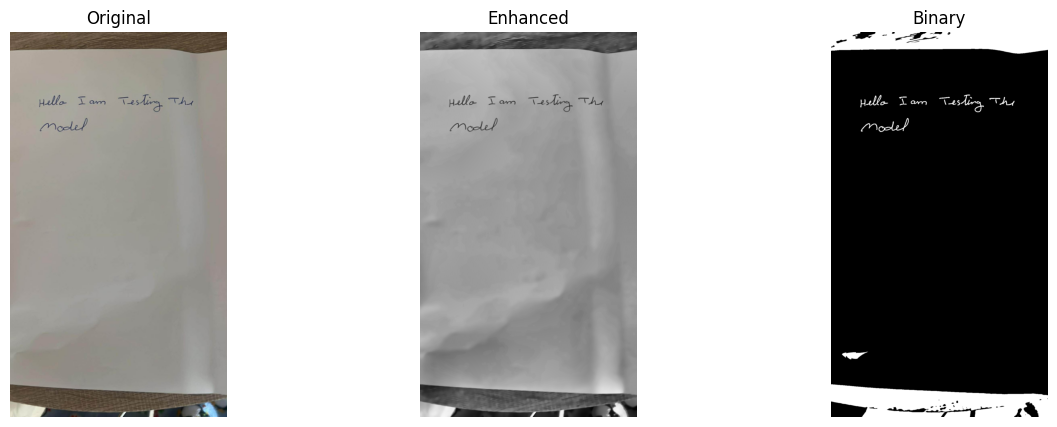

Found 6 raw lines.


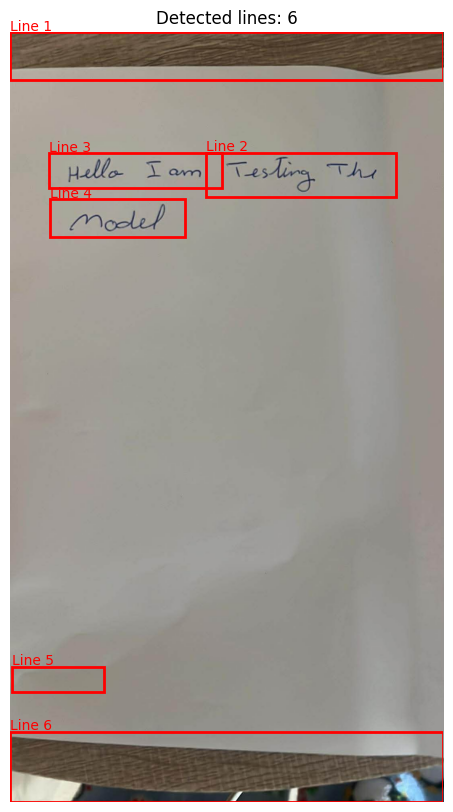

DOCUMENT HTR — FIXED PIPELINE
Image: /kaggle/input/datasets/fatmaadorgham/test-handwriting/81bcb09e-7c07-4344-80a7-eddb58c70a58.jpg

--- TrOCR ---
Found 6 raw lines.
Line 01: 2
Line 02: testing the
Line 03: Hello I am
Line 04: model .
Line 05: 0
Line 06: Print export

Final TrOCR text:
2
testing the
Hello I am
model .
0
Print export

=== TrOCR verbose ===
Found 6 raw lines.
Line 01: 2
Line 02: testing the
Line 03: Hello I am
Line 04: model .
Line 05: 0
Line 06: Print export
2
testing the
Hello I am
model .
0
Print export


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DOC_PATH ='/kaggle/input/datasets/fatmaadorgham/test-handwriting/81bcb09e-7c07-4344-80a7-eddb58c70a58.jpg'

# Debug visuel de la segmentation
visualize_lines_and_words(DOC_PATH)

# Comparer tous les modèles
results = compare_models_on_document(DOC_PATH)

print("\n=== TrOCR verbose ===")
print(read_document_trocr_fixed(DOC_PATH, verbose=True))


# 8. Evaluation and Model Comparison

This section summarizes the quantitative results of all evaluated OCR models.

The comparison is based on accuracy, Character Error Rate, and Word Error Rate.



  MODEL             ACCURACY        CER        WER
  CRNN_LSTM           72.61%      9.31%     27.39%
  CRNN_GRU            71.07%     10.01%     28.93%
  DeepCRNN            75.89%      8.51%     24.11%
  TrOCR               48.00%     39.23%     69.00%
  TrOCR               48.00%     39.23%     69.00%

  Best model: DeepCRNN  (accuracy=75.89%)


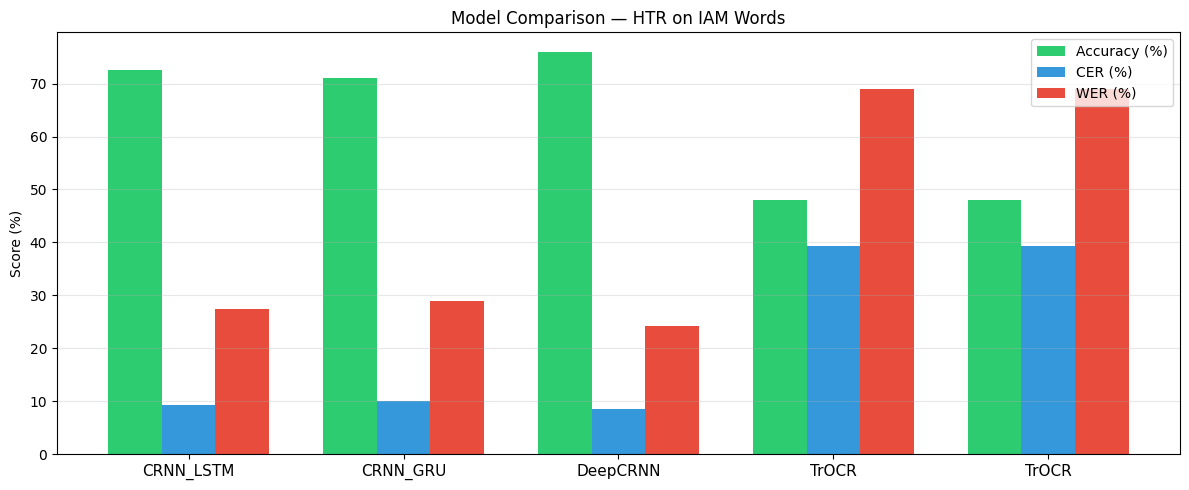

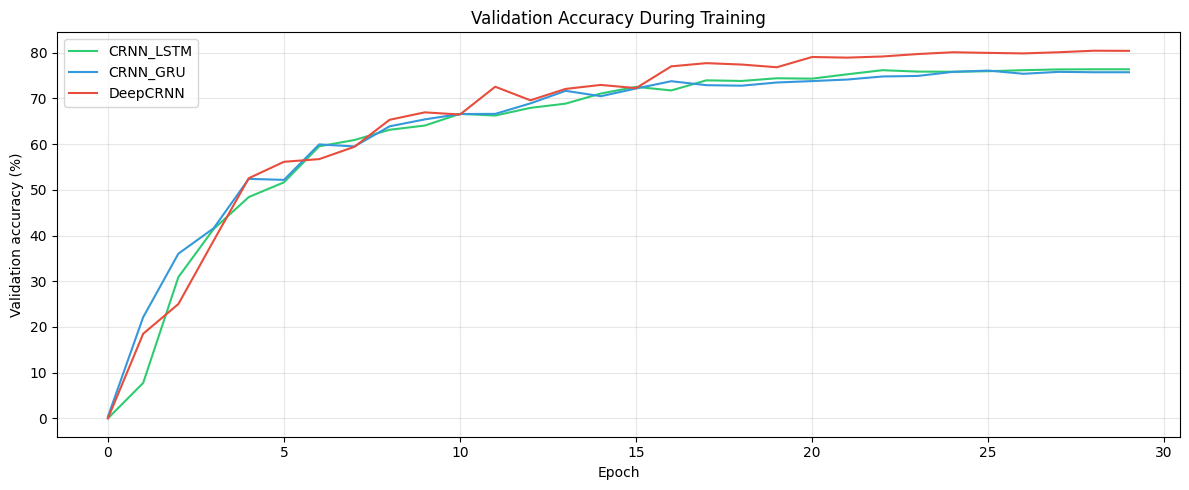

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Print summary table ───────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"  {'MODEL':<15} {'ACCURACY':>10} {'CER':>10} {'WER':>10}")
print("="*60)
for r in all_results:
    print(f"  {r['model']:<15} {r['accuracy']*100:>9.2f}% "
          f"{r['cer']*100:>9.2f}% {r['wer']*100:>9.2f}%")
print("="*60)
best = max(all_results, key=lambda x: x["accuracy"])
print(f"\n  Best model: {best['model']}  (accuracy={best['accuracy']*100:.2f}%)")

# ── Plot 1: Bar chart comparison ──────────────────────────────────────────────
names    = [r["model"]   for r in all_results]
accs     = [r["accuracy"]*100 for r in all_results]
cers     = [r["cer"]*100     for r in all_results]
wers     = [r["wer"]*100     for r in all_results]

x   = np.arange(len(names))
w   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w,  accs, w, label="Accuracy (%)",  color="#2ecc71")
ax.bar(x,      cers, w, label="CER (%)",        color="#3498db")
ax.bar(x + w,  wers, w, label="WER (%)",        color="#e74c3c")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Score (%)")
ax.set_title("Model Comparison — HTR on IAM Words")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison_bar.png", dpi=150)
plt.show()

# ── Plot 2: Validation accuracy curves during training ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ["#2ecc71", "#3498db", "#e74c3c"]
for (name, hist), color in zip(all_histories.items(), colors):
    ax.plot([a*100 for a in hist["val_acc"]], label=name, color=color)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy (%)")
ax.set_title("Validation Accuracy During Training")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_curves.png", dpi=150)
plt.show()


# 9. Explainability (XAI)

This section adds a simple saliency-based explanation for a CRNN prediction.

The saliency map highlights image regions that most influence the model output, helping us understand whether the model focuses on handwritten strokes or irrelevant background noise.


In [58]:
# ============================================================
# FIX FOR ATTENTION EXTRACTION
# ============================================================

# Force eager attention instead of SDPA
trocr_model.config._attn_implementation = "eager"

if hasattr(trocr_model, "encoder"):
    trocr_model.encoder.config._attn_implementation = "eager"

# Now attentions can be enabled
trocr_model.config.output_attentions = True

if hasattr(trocr_model, "encoder"):
    trocr_model.encoder.config.output_attentions = True

Detected lines: 6


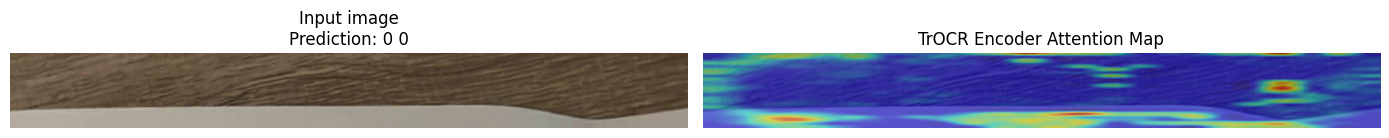

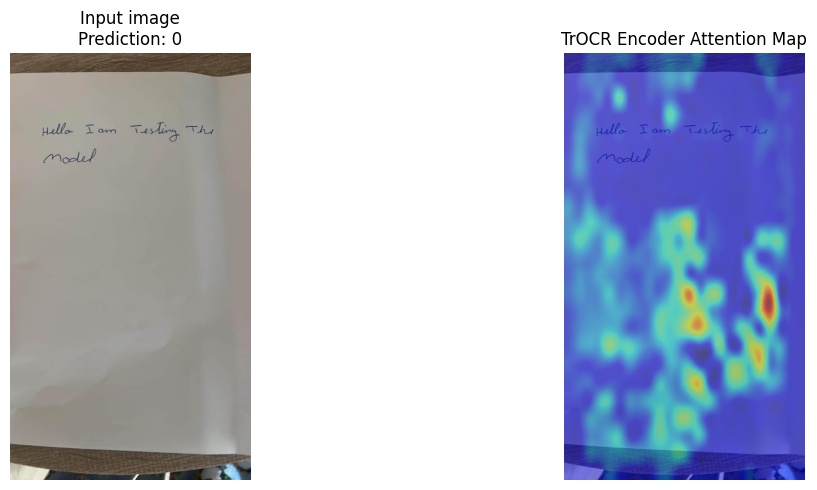

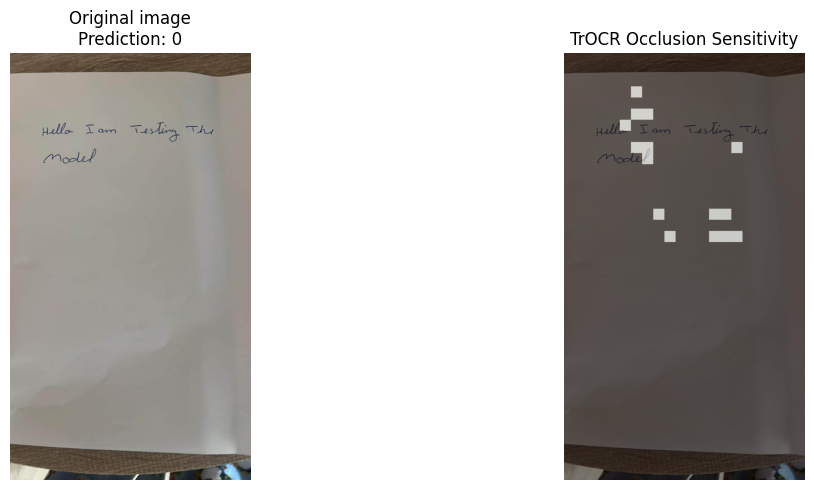

In [60]:
# ============================================================
# FIX CELL — XAI FOR TrOCR
# Safe Attention + Occlusion Sensitivity
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from difflib import SequenceMatcher

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Force attention output if supported
trocr_model.config.output_attentions = True
trocr_model.encoder.config.output_attentions = True


def predict_trocr_pil(pil_img):
    pil_img = pil_img.convert("RGB")

    pixel_values = trocr_processor(
        pil_img,
        return_tensors="pt"
    ).pixel_values.to(DEVICE)

    with torch.no_grad():
        generated_ids = trocr_model.generate(
            pixel_values,
            max_new_tokens=80
        )

    pred_text = trocr_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return pred_text


# ============================================================
# Better TrOCR XAI on cropped text line
# ============================================================

img, gray, binary = load_and_binarize_clean(XAI_IMAGE_PATH)

lines = segment_lines_robust(binary)

print(f"Detected lines: {len(lines)}")

# Take first detected line
ln = lines[0]

y0, y1 = ln["y_start"], ln["y_end"]
x0, x1 = ln["x_start"], ln["x_end"]

line_crop = img[y0:y1, x0:x1]

# Save temporary crop
temp_path = "/kaggle/working/temp_line.png"
cv2.imwrite(temp_path, line_crop)

# Run attention on cropped line
show_trocr_attention(temp_path)
def text_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()


def show_trocr_occlusion(img_path, patch_size=50, stride=50):
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

    original_pred = predict_trocr_pil(img)

    h, w, _ = img_np.shape

    heatmap = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            occluded = img_np.copy()

            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)

            occluded[y:y2, x:x2] = 255

            occluded_img = Image.fromarray(occluded)
            new_pred = predict_trocr_pil(occluded_img)

            similarity = text_similarity(original_pred, new_pred)
            importance = 1 - similarity

            heatmap[y:y2, x:x2] += importance
            counts[y:y2, x:x2] += 1

    heatmap = heatmap / (counts + 1e-8)

    heatmap = (heatmap - heatmap.min()) / (
        heatmap.max() - heatmap.min() + 1e-8
    )

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original image\nPrediction: {original_pred}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap="hot", alpha=0.5)
    plt.title("TrOCR Occlusion Sensitivity")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN XAI
# ============================================================

XAI_IMAGE_PATH = DOC_PATH

show_trocr_attention(XAI_IMAGE_PATH)

show_trocr_occlusion(
    XAI_IMAGE_PATH,
    patch_size=50,
    stride=50
)